# A/B Testing for Conversion Optimization
## End-to-End Analysis Using Frequentist and Bayesian Approaches

### Problem Statement
In digital products and e-commerce, even small improvements in conversion rates can lead to significant increases in revenue. Companies frequently use A/B testing to evaluate whether a new feature or design change improves user behavior.

In this project, we simulate an A/B test comparing two versions of a product experience:
- Version A (control)
- Version B (treatment)

The goal is to determine whether version B leads to a higher conversion rate than version A.

---

### Objective
The main objective of this analysis is to evaluate whether the observed difference in conversion rates between the two groups is statistically and practically significant.

To achieve this, we will:
- Perform exploratory data analysis (EDA)
- Conduct hypothesis testing using a frequentist approach
- Estimate confidence intervals
- Evaluate statistical power and sample size adequacy
- Analyze results across user segments (mobile vs desktop)
- Apply a Bayesian approach to estimate the probability that version B outperforms version A
- Provide a data-driven business recommendation

---

### Key Question
Should the company roll out version B based on the available evidence?

In [ ]:
#STEP 1: DATA PREPARATION

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 1000

user_id = np.arange(1, n + 1)

group = np.random.choice(['A', 'B'], size=n)

device = np.random.choice(['mobile', 'desktop'], size=n, p=[0.6, 0.4])

converted = []

for g in group:
    if g == 'A':
        converted.append(np.random.binomial(1, 0.10))
    else:
        converted.append(np.random.binomial(1, 0.13))

df = pd.DataFrame({
    'user_id': user_id,
    'group': group,
    'device': device,
    'converted': converted
})

print(df.head())

print('----------------------------')

print(df.shape)

   user_id group   device  converted
0        1     A  desktop          0
1        2     B   mobile          0
2        3     A   mobile          0
3        4     A  desktop          0
4        5     A  desktop          0
----------------------------
(1000, 4)


In [ ]:
#STEP 2: EDA (Exploratory Data Analysis)

In [ ]:
#Distribution of Users between A and B

In [ ]:
df['group'].value_counts()

,count
group,
B,510
A,490


In [ ]:
#Distribution (Device)

In [ ]:
df['device'].value_counts()

,count
device,
mobile,594
desktop,406


In [ ]:
#Global Conversion Rate

In [ ]:
df['converted'].mean()

np.float64(0.111)

In [ ]:
#Group Conversion Rate

In [ ]:
df.groupby('group')['converted'].mean()

,converted
group,
A,0.102041
B,0.119608


In [ ]:
#Number of Conversions per Group

In [ ]:
df.groupby('group')['converted'].sum()

,converted
group,
A,50
B,61


In [ ]:
#Conversion Rate (Device)

In [ ]:
df.groupby('device')['converted'].mean()

,converted
device,
desktop,0.118227
mobile,0.106061


In [ ]:
#A/B within the Device column

In [ ]:
df.groupby(['device', 'group'])['converted'].mean().unstack()

group,A,B
device,,
desktop,0.103093,0.132075
mobile,0.101351,0.110738


In [ ]:
#Barplot "Conversion Rate by Group"

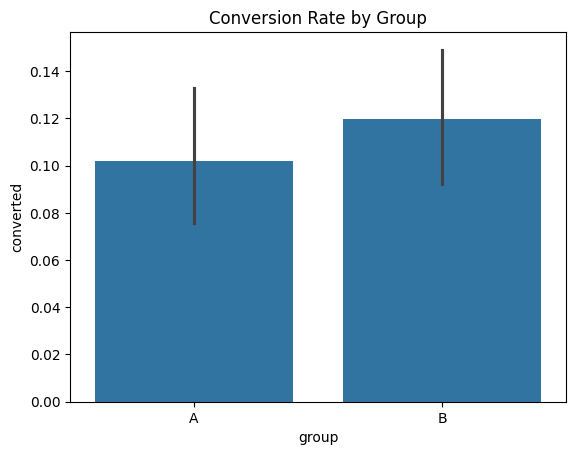

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='group', y='converted', data=df)
plt.title('Conversion Rate by Group')
plt.show()

In [ ]:
#Consideration

From the initial analysis, group B shows a higher conversion rate than group A. The difference appears to be around 0.02%. Further statistical testing is required to confirm whether this difference is significant.

In [ ]:
#Distribution Plot "Conversions by Group"

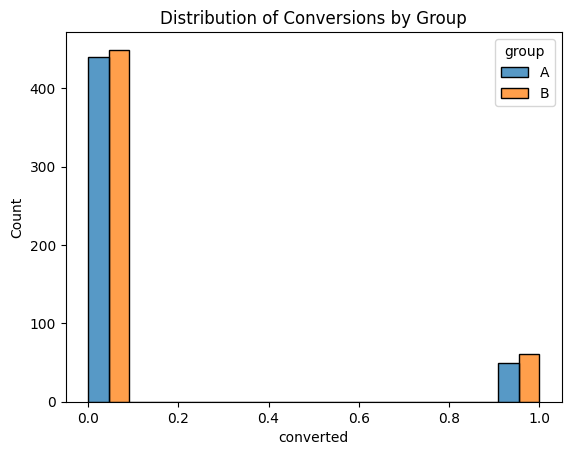

In [ ]:
sns.histplot(data=df, x='converted', hue='group', multiple='dodge')
plt.title('Distribution of Conversions by Group')
plt.show()

In [ ]:
#Consideration

The distribution plot shows that conversions are relatively rare, with most users not completing the desired action.

This class imbalance suggests that detecting small differences in conversion rates between groups may require a larger sample size, as rare events increase the variability of estimates.

In [ ]:
#STEP 3: HYPOTHESIS TESTING (FREQUENTIST APPROACH)

In [ ]:
# H0: conversion rate A = conversion rate B
# H1: conversion rate B > conversion rate A

In [ ]:
conv_A = df[df['group'] == 'A']['converted']
conv_B = df[df['group'] == 'B']['converted']

n_A = len(conv_A)
n_B = len(conv_B)

success_A = conv_A.sum()
success_B = conv_B.sum()

In [ ]:
#Z-statistic & P-value

In [ ]:
from statsmodels.stats.proportion import proportions_ztest

count = [success_A, success_B]
nobs = [n_A, n_B]

z_stat, p_value = proportions_ztest(count, nobs, alternative='larger')

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: -0.884034109868904
P-value: 0.811661100039498


In [ ]:
#Consideration

The p-value is above 0.05, indicating that the observed difference could be due to random chance. Therefore, we fail to reject the null hypothesis.

The p-value is significantly higher than 0.05, indicating that the observed difference in conversion rates between group A and group B is not statistically significant.

Although group B shows a slightly higher conversion rate, this difference could be due to random variation. Therefore, we fail to reject the null hypothesis.

In [ ]:
#STEP 4: CONFIDENCE INTERVAL ESTIMATION

In [ ]:
#How to calculate Conversion Rate

In [ ]:
cr_A = success_A / n_A
cr_B = success_B / n_B

diff = cr_B - cr_A

print("Conversion A:", cr_A)
print("Conversion B:", cr_B)
print("Difference:", diff)

Conversion A: 0.10204081632653061
Conversion B: 0.11960784313725491
Difference: 0.017567026810724293


In [ ]:
#Standard Error (SE) measurement

In [ ]:
se = np.sqrt(
    (cr_A * (1 - cr_A)) / n_A +
    (cr_B * (1 - cr_B)) / n_B
)

In [ ]:
#Confidence Interval (95%)

In [ ]:
z = 1.96  # 95%

ci_lower = diff - z * se
ci_upper = diff + z * se

print("95% CI:", (ci_lower, ci_upper))

95% CI: (np.float64(-0.021311738215949172), np.float64(0.05644579183739776))


In [ ]:
#Consideration

The 95% confidence interval includes zero, which suggests that the true difference in conversion rates could be positive or negative.

This reinforces the conclusion that the observed difference is not statistically significant.

In [ ]:
#Confidence Interval Plot

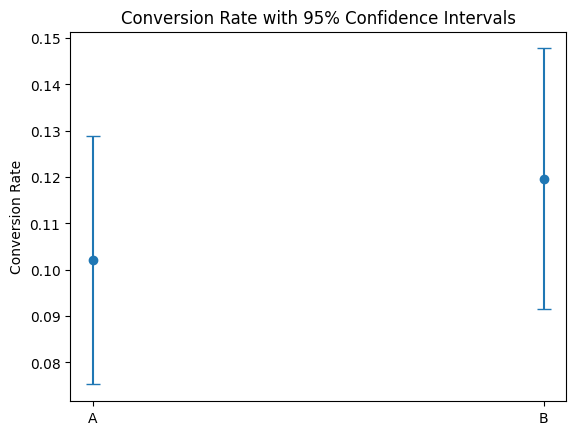

In [ ]:
cr = [cr_A, cr_B]

se_A = np.sqrt((cr_A * (1 - cr_A)) / n_A)
se_B = np.sqrt((cr_B * (1 - cr_B)) / n_B)

ci_A = [cr_A - 1.96 * se_A, cr_A + 1.96 * se_A]
ci_B = [cr_B - 1.96 * se_B, cr_B + 1.96 * se_B]

labels = ['A', 'B']

errors = [
    [cr_A - ci_A[0], cr_B - ci_B[0]],
    [ci_A[1] - cr_A, ci_B[1] - cr_B]
]

plt.errorbar(labels, cr, yerr=errors, fmt='o', capsize=5)
plt.title('Conversion Rate with 95% Confidence Intervals')
plt.ylabel('Conversion Rate')
plt.show()

In [ ]:
#Consideration

The confidence interval plot shows a significant overlap between group A and B, supporting the conclusion that the observed difference is not statistically significant.

In [ ]:
#STEP 5: POWER ANALYSIS ---> WAS THE TEST SUFFICIENTLY POWERED?

After observing a non-significant result, we perform a power analysis to evaluate whether the experiment had sufficient sample size to detect the observed effect.

In [ ]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

In [ ]:
p1 = cr_A

p2 = cr_B

effect_size = proportion_effectsize(p1, p2)

analysis = NormalIndPower()

In [ ]:
sample_size = analysis.solve_power(
    effect_size=effect_size,
    power=0.8,       # 80% power
    alpha=0.05,
    ratio=1
)

print("Required sample size per group:", int(sample_size))

Required sample size per group: 5005


In [ ]:
#Consideration

The power analysis suggests that a much larger sample size is required to reliably detect the observed effect.

Given the current sample size, the experiment is likely underpowered, meaning it may not be able to detect small but meaningful differences.

This could explain why the test did not reach statistical significance.

The power analysis indicates that approximately 5005 users per group would be required to reliably detect the observed effect size with 80% power at a 5% significance level.

Since the current experiment includes only around 500 users per group, the test is substantially underpowered.

Although version B showed a slightly higher conversion rate, the result was not statistically significant. The power analysis suggests that the experiment was underpowered, as the required sample size was far larger than the actual number of users included in the test.

For this reason, the current evidence is insufficient to support a full rollout of version B. A better next step would be to run the experiment with a larger sample size, especially to further investigate the desktop segment.

In [ ]:
#STEP 6: SEGMENTATION ANALYSIS (DEVICE-LEVEL INSIGHTS)

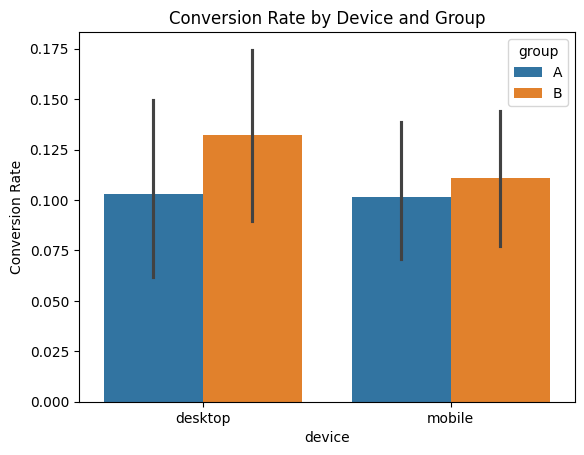

Mobile Z-statistic: -0.3714941989462738
Mobile P-value: 0.6448652620519486
Desktop Z-statistic: -0.9034587840417592
Desktop P-value: 0.816858773271384


mean  sum  count
device  group                      
desktop A      0.103093   20    194
        B      0.132075   28    212
mobile  A      0.101351   30    296
        B      0.110738   33    298

In [ ]:
#Conversion rate by device and group
df.groupby(['device', 'group'])['converted'].mean().unstack()

#Users by device and group
df.groupby(['device', 'group']).size().unstack()

#Conversions by device and group
df.groupby(['device', 'group'])['converted'].sum().unstack()

#Bar chart
sns.barplot(x='device', y='converted', hue='group', data=df)
plt.title('Conversion Rate by Device and Group')
plt.ylabel('Conversion Rate')
plt.show()

#Mobile z-test
mobile_df = df[df['device'] == 'mobile']
mobile_A = mobile_df[mobile_df['group'] == 'A']['converted']
mobile_B = mobile_df[mobile_df['group'] == 'B']['converted']

n_mobile_A = len(mobile_A)
n_mobile_B = len(mobile_B)

success_mobile_A = mobile_A.sum()
success_mobile_B = mobile_B.sum()

count_mobile = [success_mobile_A, success_mobile_B]
nobs_mobile = [n_mobile_A, n_mobile_B]

z_stat_mobile, p_value_mobile = proportions_ztest(
    count_mobile,
    nobs_mobile,
    alternative='larger'
)

print("Mobile Z-statistic:", z_stat_mobile)
print("Mobile P-value:", p_value_mobile)

#Desktop z-test
desktop_df = df[df['device'] == 'desktop']
desktop_A = desktop_df[desktop_df['group'] == 'A']['converted']
desktop_B = desktop_df[desktop_df['group'] == 'B']['converted']

n_desktop_A = len(desktop_A)
n_desktop_B = len(desktop_B)

success_desktop_A = desktop_A.sum()
success_desktop_B = desktop_B.sum()

count_desktop = [success_desktop_A, success_desktop_B]
nobs_desktop = [n_desktop_A, n_desktop_B]

z_stat_desktop, p_value_desktop = proportions_ztest(
    count_desktop,
    nobs_desktop,
    alternative='larger'
)

print("Desktop Z-statistic:", z_stat_desktop)
print("Desktop P-value:", p_value_desktop)

#Summary table
segment_summary = df.groupby(['device', 'group'])['converted'].agg(['mean', 'sum', 'count'])
segment_summary

In [ ]:
#Consideration

The segmented analysis suggests that version B performs slightly better on desktop devices compared to version A.

However, the statistical test does not show a significant difference, indicating that this observed improvement may still be due to random variation.

This suggests a potential segment-specific effect, but further testing with a larger sample size would be required to confirm it.

In [ ]:
#STEP 7: BAYESIAN A/B TESTING: PROBABILITY-BASED EVALUATION

In [ ]:
#Failures
fail_A = n_A - success_A
fail_B = n_B - success_B

#Beta Distribution Samples
samples = 10000

beta_A = np.random.beta(success_A + 1, fail_A + 1, samples)
beta_B = np.random.beta(success_B + 1, fail_B + 1, samples)

#Probability that B is better than A
prob_B_better = (beta_B > beta_A).mean()

print("Probability that B is better than A:", prob_B_better)

Probability that B is better than A: 0.8111


In [ ]:
#Posterior Distributions of CR's

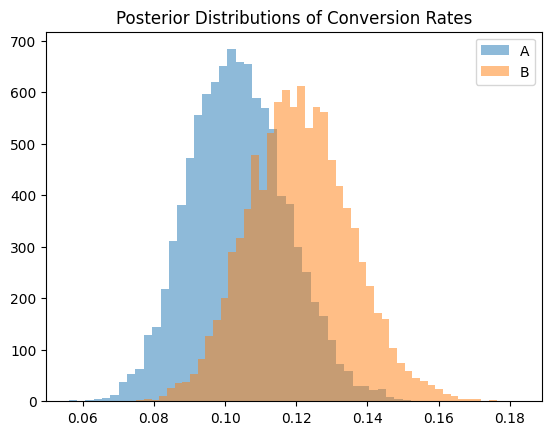

In [ ]:
plt.hist(beta_A, bins=50, alpha=0.5, label='A')
plt.hist(beta_B, bins=50, alpha=0.5, label='B')

plt.title('Posterior Distributions of Conversion Rates')
plt.legend()
plt.show()

In [ ]:
#Consideration

The Bayesian analysis shows that there is approximately a 81% probability that version B performs better than version A.

While this suggests a slight advantage for version B, the probability is not high enough to confidently support a rollout decision.

This result aligns with the frequentist approach, which also indicated a lack of statistical significance.

In [ ]:
#STEP 8: BUSINESS CONCLUSION AND RECOMMENDATIONS

Based on the results of the A/B test, there is no statistically significant evidence that version B improves conversion rates compared to version A.

Although version B shows a slightly higher conversion rate overall and appears to perform better on desktop devices, these differences are not statistically significant and may be due to random variation.

Therefore, it is not recommended to fully roll out version B at this stage.

A potential next step would be to run the experiment for a longer period or increase the sample size to better evaluate the impact, particularly within the desktop segment.